In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# EfficientNetB0 import
from tensorflow.keras.applications import EfficientNetB0
# Note: EfficientNet does NOT need a separate preprocess_input!
# It handles normalisation internally — just pass raw 0-255 pixel values
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt

In [15]:
BASE_DIR = 'smartvision_dataset'

TRAIN_DIR = f'{BASE_DIR}/classification/train'
VAL_DIR   = f'{BASE_DIR}/classification/val'
TEST_DIR  = f'{BASE_DIR}/classification/test'

os.makedirs('models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

In [16]:
# 4. IMAGE SETTINGS
# ---------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------------------------
# 5. DATA AUGMENTATION
# ---------------------------
train_datagen = ImageDataGenerator(

    # normalize pixels
    rescale=1./255,

    # augmentation
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

# validation/test → no augmentation
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [17]:
# 6. LOAD TRAIN DATA
# ---------------------------
train_gen = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=True,

    seed=42
)

# ---------------------------
# 7. LOAD VALIDATION DATA
# ---------------------------
val_gen = val_test_datagen.flow_from_directory(

    VAL_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

# ---------------------------
# 8. LOAD TEST DATA
# ---------------------------
test_gen = val_test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)


Found 1820 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.


In [18]:
# 9. LOAD PRETRAINED MODEL
# ---------------------------
base_model = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)
)

In [19]:
# 10. FREEZE BASE MODEL
# ---------------------------
base_model.trainable = False

# ---------------------------
# 11. BUILD CUSTOM MODEL
# ---------------------------
model = Sequential([

    # pretrained CNN
    base_model,

    # convert feature maps → vector
    GlobalAveragePooling2D(),

    # stabilize training
    BatchNormalization(),

    # dense learning layer
    Dense(256, activation='relu'),

    # reduce overfitting
    Dropout(0.3),

    # output layer
    Dense(train_gen.num_classes, activation='softmax')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# save best model automatically
checkpoint = ModelCheckpoint(

    'models/efficientnetb0_best.h5',

    monitor='val_accuracy',

    save_best_only=True
)

In [23]:
# 14. TRAIN MODEL
# ---------------------------
history = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=25,

    callbacks=[early_stop, checkpoint]
)


Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.0319 - loss: 3.7684

57/57 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.0357 - loss: 3.7474 - val_accuracy: 0.0385 - val_loss: 3.2843
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 53s 932ms/step - accuracy: 0.0319 - loss: 3.6295 - val_accuracy: 0.0385 - val_loss: 3.2716
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0379 - loss: 3.5432 - val_accuracy: 0.0385 - val_loss: 3.2601
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 55s 968ms/step - accuracy: 0.0412 - loss: 3.5210 - val_accuracy: 0.0385 - val_loss: 3.2589
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 52s 906ms/step - accuracy: 0.0429 - loss: 3.4760 - val_accuracy: 0.0385 - val_loss: 3.2579
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 54s 951ms/step - accuracy: 0.0456 - loss: 3.3926 - val_accuracy: 0.0385 - val_loss: 3.2581
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0412 - loss: 3.3628 - val_accuracy: 0.0385 - val_loss: 3.2581
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0269 - loss: 3.3479 - val_accuracy: 0.0385 - val_loss

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)

print("\nTest Accuracy:", test_acc)

In [ ]:
model.save('models/efficientnetb0_final.h5')

print("\nModel Saved Successfully")


✅ EfficientNetB0 model saved


In [23]:
pred_probs = model.predict(test_gen)

y_pred = np.argmax(pred_probs, axis=1)

y_true = test_gen.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step 


In [24]:
class_names = list(test_gen.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

     airplane       0.72      0.87      0.79        15
          bed       0.62      0.67      0.65        15
        bench       0.29      0.27      0.28        15
      bicycle       0.32      0.73      0.45        15
         bird       0.40      0.13      0.20        15
       bottle       0.89      0.53      0.67        15
         bowl       0.29      0.53      0.37        15
          bus       0.36      0.33      0.34        15
         cake       0.33      0.13      0.19        15
          car       0.00      0.00      0.00        15
          cat       0.76      0.87      0.81        15
        chair       0.00      0.00      0.00        15
        couch       0.55      0.40      0.46        15
          cow       0.64      0.60      0.62        15
          cup       0.10      0.07      0.08        15
          dog       0.38      0.20      0.26        15
     elephant       0.88      0.93      0.90        15
        h

In [25]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Evaluation Metrics
------------------
Accuracy : 0.4308
Precision: 0.4295
Recall   : 0.4308
F1 Score : 0.4060


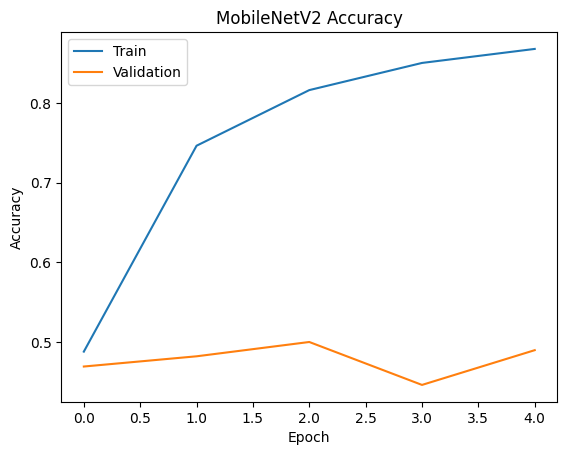

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()